# Исследование данных по продажам за 2023г.

#### **Загрузка данных**

In [17]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("/Users/liu/Downloads/sales.csv")

In [18]:
print(f"Загружено строк: {len(df):,}")

Загружено строк: 2,040,076


#### **Исследовательский анализ данных**

In [19]:
print("Размер данных:", df.shape)
print("\nПропуски:")
display(df.isna().sum())

print("Полные дубликаты:", df.duplicated().sum())

print("\nПроверка значений:")
checks = {
    "quantity < 0": (df["quantity"] < 0).sum(),
    "quantity == 0": (df["quantity"] == 0).sum(),
    "price_per_item <= 0": (df["price_per_item"] <= 0).sum(),
    "discount_per_item < 0": (df["discount_per_item"] < 0).sum(),
    "discount > price": (df["discount_per_item"] > df["price_per_item"]).sum(),
    "total_price < 0": (df["total_price"] < 0).sum(),
    "total_price == 0": (df["total_price"] == 0).sum(),
    "time == 86400": (df["purchase_time_as_seconds_from_midnight"] == 86400).sum(),
}
display(pd.Series(checks))

print(
    "\nСтроки quantity = 0 и total_price = 0:",
    ((df["quantity"] == 0) & (df["total_price"] == 0)).sum()
)

print(
    "Строки quantity > 0 и total_price = 0:",
    ((df["quantity"] > 0) & (df["total_price"] == 0)).sum()
)

Размер данных: (2040076, 9)

Пропуски:


client_id                                 0
discount_per_item                         0
gender                                    0
price_per_item                            0
product_id                                0
purchase_datetime                         0
purchase_time_as_seconds_from_midnight    0
quantity                                  0
total_price                               0
dtype: int64

Полные дубликаты: 0

Проверка значений:


quantity < 0                 0
quantity == 0            40399
price_per_item <= 0          0
discount_per_item < 0        0
discount > price             0
total_price < 0              0
total_price == 0         40657
time == 86400               34
dtype: int64


Строки quantity = 0 и total_price = 0: 40399
Строки quantity > 0 и total_price = 0: 258


#### **Основные показатели**

In [8]:
summary = pd.DataFrame({
    "Показатель": [
        "Транзакции",
        "Уникальные клиенты",
        "Уникальные товары",
        "Продано единиц",
        "Выручка",
        "Средняя выручка на транзакцию",
        "Медианная выручка на транзакцию"
    ],
    "Значение": [
        len(df),
        df["client_id"].nunique(),
        df["product_id"].nunique(),
        df["quantity"].sum(),
        df["total_price"].sum(),
        df["total_price"].mean(),
        df["total_price"].median()
    ]
})

summary

,Показатель,Значение
0,Транзакции,2.040076e+06
1,Уникальные клиенты,8.699660e+05
2,Уникальные товары,5.000000e+04
3,Продано единиц,6.727579e+07
4,Выручка,1.674710e+12
5,Средняя выручка на транзакцию,8.209055e+05
6,Медианная выручка на транзакцию,4.009175e+05


#### **Метрики товаров и лидеры**

In [9]:
product_stats = (
    df.groupby("product_id")
      .agg(
          revenue=("total_price", "sum"),
          quantity=("quantity", "sum"),
          transactions=("product_id", "size"),
          clients=("client_id", "nunique"),
          avg_price=("price_per_item", "mean"),
          avg_discount=("discount_per_item", "mean")
      )
      .reset_index()
)

product_stats["revenue_share"] = (
    product_stats["revenue"]
    / product_stats["revenue"].sum()
    * 100
)

top_revenue = product_stats.nlargest(
    10, "revenue"
)[[
    "product_id", "revenue", "quantity",
    "transactions", "clients", "avg_price",
    "avg_discount", "revenue_share"
]]

top_quantity = product_stats.nlargest(
    10, "quantity"
)[[
    "product_id", "revenue", "quantity",
    "transactions", "clients", "avg_price",
    "avg_discount", "revenue_share"
]]

print("ТОП-10 по выручке")
display(top_revenue)

print("ТОП-10 по количеству")
display(top_quantity)

ТОП-10 по выручке


,product_id,revenue,quantity,transactions,clients,avg_price,avg_discount,revenue_share
37181,37181,126506926.0,2348,60,60,99128.0,45848.900000,0.007554
30239,30239,122577085.0,2121,50,50,97163.0,39495.620000,0.007319
22406,22406,122007891.0,2119,51,51,98105.0,46210.313725,0.007285
10292,10292,121115031.0,2202,64,64,99602.0,40669.484375,0.007232
45018,45018,118322228.0,2235,61,61,96227.0,42324.557377,0.007065
24299,24299,117852522.0,2074,59,59,97297.0,43744.271186,0.007037
11714,11714,113646456.0,1963,55,55,97518.0,44929.363636,0.006786
40657,40657,113584037.0,2108,54,54,98872.0,45927.296296,0.006782
696,696,112019601.0,2425,64,64,86187.0,38096.703125,0.006689
182,182,110779224.0,2413,59,59,92766.0,43478.508475,0.006615


ТОП-10 по количеству


,product_id,revenue,quantity,transactions,clients,avg_price,avg_discount,revenue_share
25856,25856,49376030.0,2714,71,71,41080.0,21299.816901,0.002948
46596,46596,2480628.0,2539,63,63,2066.0,1070.412698,0.000148
44229,44229,14852502.0,2533,69,69,11854.0,6048.782609,0.000887
16114,16114,70390279.0,2484,66,66,55532.0,27137.651515,0.004203
40138,40138,98261634.0,2434,59,59,85918.0,48197.254237,0.005867
27636,27636,74918055.0,2431,63,63,52632.0,23202.238095,0.004473
696,696,112019601.0,2425,64,64,86187.0,38096.703125,0.006689
182,182,110779224.0,2413,59,59,92766.0,43478.508475,0.006615
25477,25477,798038.0,2408,67,66,636.0,306.253731,0.000048
46898,46898,87055911.0,2387,59,59,70015.0,34103.355932,0.005198


#### **АВС анализ ассортиммента**

In [10]:
product_abc = product_stats.sort_values(
    "revenue",
    ascending=False
).copy()

product_abc["cumulative_revenue_share"] = (
    product_abc["revenue"].cumsum()
    / product_abc["revenue"].sum()
    * 100
)

product_abc["abc_group"] = pd.cut(
    product_abc["cumulative_revenue_share"],
    bins=[0, 80, 95, 100],
    labels=["A", "B", "C"],
    include_lowest=True
)

abc_summary = (
    product_abc.groupby("abc_group", observed=True)
    .agg(
        products=("product_id", "count"),
        revenue=("revenue", "sum"),
        quantity=("quantity", "sum")
    )
    .reset_index()
)

abc_summary["revenue_share"] = (
    abc_summary["revenue"]
    / product_abc["revenue"].sum()
    * 100
)

abc_summary["quantity_share"] = (
    abc_summary["quantity"]
    / product_abc["quantity"].sum()
    * 100
)

abc_summary.round(2)

,abc_group,products,revenue,quantity,revenue_share,quantity_share
0,A,26996,1.339758e+12,37513389,80.0,55.76
1,B,11509,2.512082e+11,14878224,15.0,22.12
2,C,11495,8.374317e+10,14884173,5.0,22.12


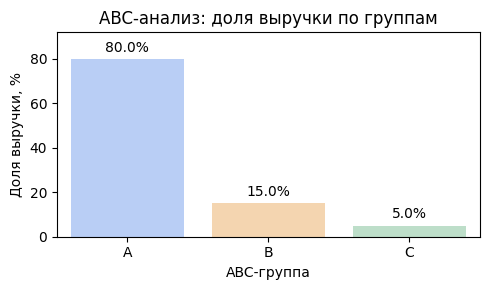

In [11]:
plt.figure(figsize=(5, 3))

ax = sns.barplot(
    data=abc_summary,
    x="abc_group",
    y="revenue_share",
    hue="abc_group",
    palette=["#AFCBFF", "#FFD6A5", "#B7E4C7"],
    legend=False
)

plt.title("ABC-анализ: доля выручки по группам")
plt.xlabel("ABC-группа")
plt.ylabel("Доля выручки, %")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.ylim(0, abc_summary["revenue_share"].max() * 1.15)
plt.tight_layout()
plt.show()

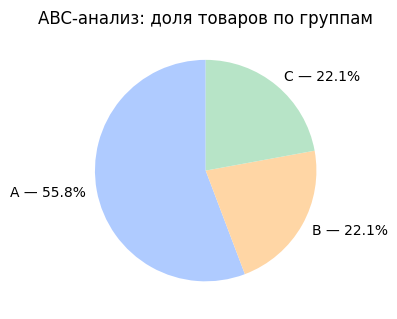

In [12]:
plt.figure(figsize=(4, 4))

labels = [
    f"{group} — {share:.1f}%"
    for group, share in zip(
        abc_summary["abc_group"],
        abc_summary["quantity_share"]
    )
]

plt.pie(
    abc_summary["quantity_share"],
    labels=labels,
    colors=["#AFCBFF", "#FFD6A5", "#B7E4C7"],
    startangle=90
)

plt.title("ABC-анализ: доля товаров по группам")
plt.tight_layout()
plt.show()

#### **Проверка товаров категории "С" с высоким объемом**

In [13]:
c_high_volume = (
    product_abc[
        product_abc["abc_group"] == "C"
    ]
    .nlargest(20, "quantity")
)[[
    "product_id",
    "revenue",
    "quantity",
    "transactions",
    "clients",
    "avg_price",
    "avg_discount",
    "abc_group"
]]

c_high_volume

,product_id,revenue,quantity,transactions,clients,avg_price,avg_discount,abc_group
46596,46596,2480628.0,2539,63,63,2066.0,1070.412698,C
25477,25477,798038.0,2408,67,66,636.0,306.253731,C
36112,36112,13836950.0,2355,62,62,12487.0,6329.193548,C
31950,31950,12077538.0,2321,56,56,10178.0,4917.535714,C
8486,8486,5178258.0,2316,52,52,4188.0,2018.769231,C
6285,6285,11110115.0,2289,64,64,10356.0,5213.593750,C
24854,24854,11775329.0,2268,57,57,10622.0,5415.807018,C
10816,10816,2141697.0,2262,64,64,1657.0,790.609375,C
13335,13335,11554701.0,2253,55,55,9089.0,3774.418182,C
11756,11756,1790976.0,2245,59,59,1514.0,737.593220,C


In [14]:
# C-товары с низким объемом и низкой выручкой — первичный список на ревизию
# Рассчитываем 25-й перцентиль
q25_qty = product_abc["quantity"].quantile(0.25)
q25_rev = product_abc["revenue"].quantile(0.25)

c_low_volume = (
    product_abc[
        (product_abc["abc_group"] == "C") &
        (product_abc["quantity"] <= q25_qty) &
        (product_abc["revenue"] <= q25_rev)
    ]
    .sort_values("revenue")
    .copy()
)

c_low_volume_summary = pd.DataFrame({
    "Показатель": [
        "Количество C-SKU в первичной зоне ревизии",
        "Доля C-SKU в этой зоне, %",
        "Выручка зоны, ₽",
        "Доля общей выручки, %"
    ],
    "Значение": [
        len(c_low_volume),
        len(c_low_volume) / len(product_abc) * 100,
        c_low_volume["revenue"].sum(),
        c_low_volume["revenue"].sum()
        / product_abc["revenue"].sum() * 100
    ]
})

c_low_volume_summary.round(2)

,Показатель,Значение
0,Количество C-SKU в первичной зоне ревизии,3.645000e+03
1,"Доля C-SKU в этой зоне, %",7.290000e+00
2,"Выручка зоны, ₽",2.655444e+10
3,"Доля общей выручки, %",1.590000e+00


#### **Анализ скидок**

In [15]:
df["discount_rate"] = (
    df["discount_per_item"]
    / df["price_per_item"]
    * 100
)

df["discount_group"] = pd.cut(
    df["discount_rate"],
    bins=[-0.01, 20, 40, 60, 80, 100],
    labels=["0–20%", "20–40%", "40–60%", "60–80%", "80–100%"]
)

discount_analysis = (
    df.groupby("discount_group", observed=True)
      .agg(
          transactions=("product_id", "size"),
          quantity=("quantity", "sum"),
          revenue=("total_price", "sum")
      )
      .reset_index()
)

discount_analysis["revenue_per_transaction"] = (
    discount_analysis["revenue"] / discount_analysis["transactions"]
)

discount_analysis["quantity_per_transaction"] = (
    discount_analysis["quantity"] / discount_analysis["transactions"]
)

discount_analysis["realized_unit_price"] = (
    discount_analysis["revenue"] / discount_analysis["quantity"]
)

discount_analysis

,discount_group,transactions,quantity,revenue,revenue_per_transaction,quantity_per_transaction,realized_unit_price
0,0–20%,408483,13437466,6.018406e+11,1.473355e+06,32.896023,44788.252459
1,20–40%,408003,13468028,4.693090e+11,1.150259e+06,33.009630,34846.158610
2,40–60%,407237,13449477,3.356988e+11,8.243327e+05,33.026167,24959.986544
3,60–80%,407091,13421406,2.005289e+11,4.925898e+05,32.969056,14940.972674
4,80–100%,409262,13499409,6.733242e+10,1.645216e+05,32.984760,4987.804957


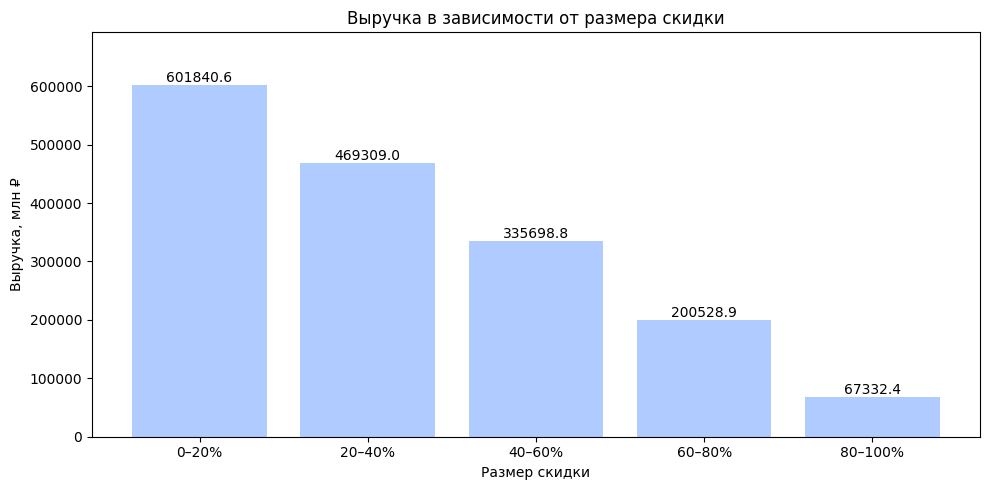

In [16]:
discount_analysis["revenue_mln"] = (
    discount_analysis["revenue"] / 1000000
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    discount_analysis["discount_group"],
    discount_analysis["revenue_mln"],
    color="#AFCBFF"
)

plt.title("Выручка в зависимости от размера скидки")
plt.xlabel("Размер скидки")
plt.ylabel("Выручка, млн ₽")

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, discount_analysis["revenue_mln"].max() * 1.15)
plt.tight_layout()
plt.show()

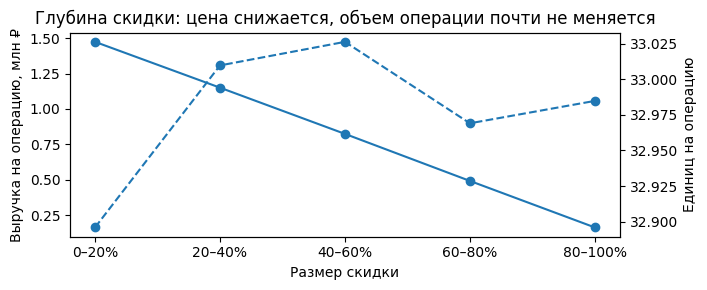

In [16]:
fig, ax = plt.subplots(figsize=(7, 3))

x = np.arange(len(discount_analysis))

ax.plot(
    x,
    discount_analysis["revenue_per_transaction"] / 1e6,
    marker="o",
    label="Выручка на операцию, млн ₽"
)

ax2 = ax.twinx()
ax2.plot(
    x,
    discount_analysis["quantity_per_transaction"],
    marker="o",
    linestyle="--",
    label="Единиц на операцию"
)

ax.set_xticks(x)
ax.set_xticklabels(discount_analysis["discount_group"])
ax.set_xlabel("Размер скидки")
ax.set_ylabel("Выручка на операцию, млн ₽")
ax2.set_ylabel("Единиц на операцию")
ax.set_title("Глубина скидки: цена снижается, объем операции почти не меняется")

plt.tight_layout()
plt.show()

In [17]:
# Сколько объема можно потерять, чтобы переход на менее глубокую скидку
d = discount_analysis.copy()

d["break_even_quantity_decline_to_previous_band"] = np.nan

for i in range(1, len(d)):
    current_price = d.loc[i, "realized_unit_price"]
    previous_price = d.loc[i - 1, "realized_unit_price"]

    price_multiplier = previous_price / current_price

    d.loc[i, "break_even_quantity_decline_to_previous_band"] = (
        1 - 1 / price_multiplier
    ) * 100

d[[
    "discount_group",
    "realized_unit_price",
    "quantity_per_transaction",
    "revenue_per_transaction",
    "break_even_quantity_decline_to_previous_band"
]].round(2)

,discount_group,realized_unit_price,quantity_per_transaction,revenue_per_transaction,break_even_quantity_decline_to_previous_band
0,0–20%,44788.25,32.90,1473355.37,NaN
1,20–40%,34846.16,33.01,1150258.80,22.20
2,40–60%,24959.99,33.03,824332.67,28.37
3,60–80%,14940.97,32.97,492589.77,40.14
4,80–100%,4987.80,32.98,164521.55,66.62


In [18]:
product_abc['discount_rate'] = product_abc['avg_discount'] / product_abc['avg_price'] * 100

# Сегментируем группу C на подгруппы для принятия решений
c_group = product_abc[product_abc['abc_group'] == 'C'].copy()

# Находим товары C с высоким объемом, но высокой скидкой (кандидаты на повышение цены или вывод)
c_high_vol_high_disc = c_group[(c_group['quantity'] > c_group['quantity'].quantile(0.75)) & 
                               (c_group['discount_rate'] > c_group['discount_rate'].quantile(0.75))]

# Находим товары C с высоким объемом, но низкой скидкой (хорошие "локомотивы" трафика)
c_high_vol_low_disc = c_group[(c_group['quantity'] > c_group['quantity'].quantile(0.75)) & 
                              (c_group['discount_rate'] <= c_group['discount_rate'].quantile(0.25))]

print(f"В группе C найдено {len(c_high_vol_high_disc)} товаров-паразитов (высокий объем, высокая скидка).")
print(f"В группе C найдено {len(c_high_vol_low_disc)} товаров-локомотивов (высокий объем, низкая скидка).")

В группе C найдено 651 товаров-паразитов (высокий объем, высокая скидка).
В группе C найдено 659 товаров-локомотивов (высокий объем, низкая скидка).


In [19]:
a_group = product_abc[product_abc['abc_group'] == 'A'].nlargest(100, 'revenue')
# Сколько из топ-100 товаров А продаются со скидкой более 20%?
a_overdiscounted = a_group[a_group['discount_rate'] > 20]
print(f"Из топ-100 товаров группы А, {len(a_overdiscounted)} продаются со скидкой >20%, хотя данные показывают, что макс. выручка в диапазоне 0-20%.")

Из топ-100 товаров группы А, 100 продаются со скидкой >20%, хотя данные показывают, что макс. выручка в диапазоне 0-20%.


#### **Оптимизация ассортиментной матрицы и ценовой политики**

In [20]:
# Подготовка расширенной таблицы SKU
sku = (
    df.groupby("product_id")
      .agg(
          revenue=("total_price", "sum"),
          quantity=("quantity", "sum"),
          transactions=("product_id", "size"),
          clients=("client_id", "nunique"),
          avg_list_price=("price_per_item", "mean"),
          avg_discount=("discount_per_item", "mean"),
          avg_discount_rate=("discount_rate", "mean")
      )
      .reset_index()
)

sku["realized_price"] = sku["revenue"] / sku["quantity"]
sku["revenue_share"] = sku["revenue"] / sku["revenue"].sum() * 100

q25_qty, q50_qty, q75_qty = sku["quantity"].quantile([.25, .50, .75])
q25_rev, q50_rev, q75_rev = sku["revenue"].quantile([.25, .50, .75])

# Матрица управленческих действий
sku["action_group"] = np.select(
    [
        (sku["quantity"] >= q75_qty) & (sku["revenue"] >= q75_rev),
        (sku["quantity"] >= q75_qty) & (sku["revenue"] < q50_rev),
        (sku["revenue"] >= q75_rev) & (sku["quantity"] < q50_qty),
        (sku["quantity"] <= q25_qty) & (sku["revenue"] <= q25_rev),
    ],
    [
        "Лидеры: защищать наличие",
        "Высокий объем / низкая выручка: тест цены",
        "Высокая выручка / низкий объем: развивать точечно",
        "Низкий объем / низкая выручка: кандидат на вывод",
    ],
    default="Средняя зона: стандартное управление"
)

matrix_summary = (
    sku.groupby("action_group")
       .agg(
           sku=("product_id", "count"),
           revenue=("revenue", "sum"),
           quantity=("quantity", "sum"),
           avg_discount_rate=("avg_discount_rate", "mean")
       )
       .reset_index()
)

matrix_summary["revenue_share"] = (
    matrix_summary["revenue"] / sku["revenue"].sum() * 100
)

matrix_summary.sort_values("revenue", ascending=False).round(2)

,action_group,sku,revenue,quantity,avg_discount_rate,revenue_share
4,Средняя зона: стандартное управление,32517,1.019911e+12,42151313,50.19,60.90
2,Лидеры: защищать наличие,5151,3.468890e+11,8752661,49.42,20.71
0,Высокая выручка / низкий объем: развивать точечно,3557,2.002235e+11,4313152,48.13,11.96
1,Высокий объем / низкая выручка: тест цены,4803,7.616516e+10,8039959,50.34,4.55
3,Низкий объем / низкая выручка: кандидат на вывод,3972,3.152085e+10,4018701,50.52,1.88


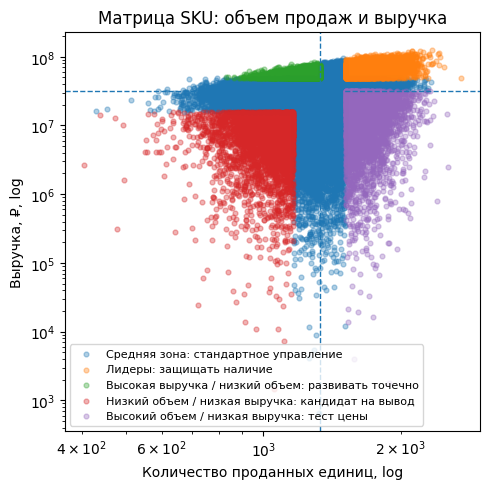

In [21]:
plt.figure(figsize=(5, 5))

for group in sku["action_group"].unique():
    part = sku[sku["action_group"] == group]
    plt.scatter(
        part["quantity"],
        part["revenue"],
        s=12,
        alpha=0.35,
        label=group
    )

plt.axvline(q50_qty, linestyle="--", linewidth=1)
plt.axhline(q50_rev, linestyle="--", linewidth=1)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Количество проданных единиц, log")
plt.ylabel("Выручка, ₽, log")
plt.title("Матрица SKU: объем продаж и выручка")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [22]:
# C-товары с низким объёмом и низкой выручкой — первичный список на ревизию
c_low_volume = (
    sku.merge(product_abc[["product_id", "abc_group"]], on="product_id", how="left")
       .query("abc_group == 'C'")
       .query("quantity <= @q25_qty and revenue <= @q25_rev")
       .sort_values("revenue")
)

c_low_volume_summary = pd.DataFrame({
    "Показатель": [
        "Количество C-SKU в первичной зоне ревизии",
        "Доля C-SKU в этой зоне",
        "Выручка зоны, ₽",
        "Доля общей выручки, %"
    ],
    "Значение": [
        len(c_low_volume),
        len(c_low_volume) / len(sku) * 100,
        c_low_volume["revenue"].sum(),
        c_low_volume["revenue"].sum() / sku["revenue"].sum() * 100
    ]
})

c_low_volume_summary.round(2)

,Показатель,Значение
0,Количество C-SKU в первичной зоне ревизии,3.645000e+03
1,Доля C-SKU в этой зоне,7.290000e+00
2,"Выручка зоны, ₽",2.655444e+10
3,"Доля общей выручки, %",1.590000e+00


#### **Динамика продаж по месяцам**

In [23]:
monthly_sales = (
    df.assign(month=df["purchase_datetime"].dt.to_period("M"))
      .groupby("month")
      .agg(
          transactions=("product_id", "size"),
          quantity=("quantity", "sum"),
          revenue=("total_price", "sum"),
          clients=("client_id", "nunique")
      )
      .reset_index()
)

monthly_sales["revenue_change_pct"] = (
    monthly_sales["revenue"].pct_change() * 100
)

monthly_sales["month"] = monthly_sales["month"].astype(str)

monthly_sales

,month,transactions,quantity,revenue,clients,revenue_change_pct
0,2023-01,150672,4962561,1.226161e+11,139862,NaN
1,2023-02,160412,5309605,1.322432e+11,148197,7.851416
2,2023-03,191359,6301623,1.568222e+11,174328,18.586226
3,2023-04,153072,5045183,1.255992e+11,142069,-19.909827
4,2023-05,180641,5952731,1.484285e+11,165238,18.176282
5,2023-06,178938,5919550,1.480808e+11,163814,-0.234219
6,2023-07,174703,5751887,1.434487e+11,160226,-3.128106
7,2023-08,172581,5674516,1.413407e+11,158578,-1.469469
8,2023-09,181420,5989500,1.485313e+11,166123,5.087399
9,2023-10,172079,5680292,1.408496e+11,158274,-5.171795


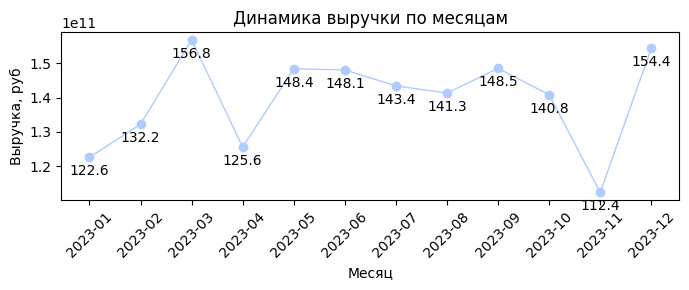

In [24]:
plt.figure(figsize=(7, 3))

plt.plot(
    monthly_sales["month"],
    monthly_sales["revenue"],
    marker='o',
    linewidth=1,
    color="#AFCBFF"
)

plt.title("Динамика выручки по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Выручка, руб")
plt.xticks(rotation=45)

for x, y in zip(monthly_sales["month"], monthly_sales["revenue"]):
    plt.annotate(
        f"{y / 1e9:.1f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        va="bottom"
    )


plt.tight_layout()
plt.show()

#### **Частота покупок и одноразовые/повторные клиенты**

In [25]:
client_purchase_frequency = (
    df.groupby("client_id")
      .agg(
          transactions=("purchase_datetime", "size"),
          quantity=("quantity", "sum"),
          revenue=("total_price", "sum"),
          unique_products=("product_id", "nunique")
      )
      .reset_index()
)

client_segments = (
    client_purchase_frequency
    .assign(
        client_type=lambda x: np.where(
            x["transactions"] == 1,
            "Одноразовый",
            "Повторный"
        )
    )
    .groupby("client_type")
    .agg(
        clients=("client_id", "count"),
        transactions=("transactions", "sum"),
        quantity=("quantity", "sum"),
        revenue=("revenue", "sum"),
        avg_revenue_per_client=("revenue", "mean"),
        avg_transactions_per_client=("transactions", "mean")
    )
    .reset_index()
)

In [26]:
client_segments["client_share"] = (
    client_segments["clients"]
    / client_segments["clients"].sum()
    * 100
)

client_segments["revenue_share"] = (
    client_segments["revenue"]
    / client_segments["revenue"].sum()
    * 100
)
client_segments.round(2)

,client_type,clients,transactions,quantity,revenue,avg_revenue_per_client,avg_transactions_per_client,client_share,revenue_share
0,Одноразовый,264955,264955,8732578,2.169134e+11,818680.24,1.00,30.46,12.95
1,Повторный,605011,1775121,58543208,1.457796e+12,2409536.82,2.93,69.54,87.05


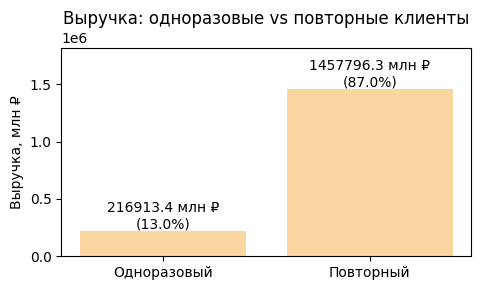

In [27]:
client_segments["revenue_mln"] = (
    client_segments["revenue"] / 1000000
)

plt.figure(figsize=(5, 3))

bars = plt.bar(
    client_segments["client_type"],
    client_segments["revenue_mln"],
    color="#FAD7A0"
)

plt.title("Выручка: одноразовые vs повторные клиенты")
plt.xlabel("")
plt.ylabel("Выручка, млн ₽")
plt.ylim(0, client_segments["revenue_mln"].max() * 1.25)

for bar, share in zip(
    bars,
    client_segments["revenue_share"]
):
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f} млн ₽\n({share:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### **Связь частоты покупок с исторической ценностью**

In [28]:
frequency_summary = (
    client_purchase_frequency
    .groupby("transactions")
    .agg(
        clients=("client_id", "count"),
        revenue=("revenue", "sum"),
        avg_revenue=("revenue", "mean"),
        avg_unique_products=("unique_products", "mean")
    )
    .reset_index()
)

frequency_summary.head(6).round(2)

,transactions,clients,revenue,avg_revenue,avg_unique_products
0,1,264955,2.169134e+11,818680.24,1.0
1,2,270786,4.435455e+11,1637992.67,2.0
2,3,183940,4.541380e+11,2468946.47,3.0
3,4,94111,3.097608e+11,3291441.04,4.0
4,5,38285,1.568888e+11,4097917.36,5.0
5,6,12921,6.368004e+10,4928414.25,6.0


#### **Интервалы между покупками**

In [29]:
client_purchase_dates = (
    df[["client_id", "purchase_datetime"]]
    .sort_values(["client_id", "purchase_datetime"])
    .copy()
)

client_purchase_dates["days_since_previous"] = (
    client_purchase_dates
    .groupby("client_id")["purchase_datetime"]
    .diff()
    .dt.days
)

purchase_intervals = client_purchase_dates[
    "days_since_previous"
].dropna()

purchase_intervals.describe().round(2)

count    1170110.00
mean          85.72
std           71.21
min            0.00
25%           29.00
50%           67.00
75%          126.00
max          363.00
Name: days_since_previous, dtype: float64

#### **RFM метрики**

In [30]:
analysis_date = df["purchase_datetime"].max()

rfm = (
    df.groupby("client_id")
      .agg(
          recency=(
              "purchase_datetime",
              lambda x: (analysis_date - x.max()).days
          ),
          frequency=("purchase_datetime", "size"),
          monetary=("total_price", "sum")
      )
      .reset_index()
)

rfm.describe().round(2)

,client_id,recency,frequency,monetary
count,869966.00,869966.00,869966.00,869966.00
mean,500156.90,124.05,2.35,1925028.91
std,288692.85,94.78,1.28,1943921.45
min,0.00,0.00,1.00,0.00
25%,250280.25,42.00,1.00,456600.50
50%,500186.00,104.00,2.00,1316745.50
75%,750249.75,188.00,3.00,2796604.75
max,999998.00,364.00,12.00,21738645.00


#### **RFM сегментация**

In [39]:
# RFM-оценки по квантилям
# R: чем меньше дней с последней покупки, тем выше балл
rfm["r_score"] = pd.qcut(
    rfm["recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

# F и M: чем выше показатель, тем выше балл
rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm_final = rfm.copy()
rfm_final["final_segment"] = np.select(
    [
        # Свежие одноразовые: задача — получить вторую покупку
        (rfm_final["frequency"] == 1) &
        (rfm_final["recency"] <= 90),

        # Одноразовые с давней покупкой: реактивация
        (rfm_final["frequency"] == 1) &
        (rfm_final["recency"] > 90),

        # Активные ценные: удержание и развитие
        (rfm_final["recency"] <= 31) &
        (rfm_final["f_score"] >= 4) &
        (rfm_final["m_score"] >= 4),

        # Ценные в зоне риска
        (rfm_final["recency"] >= 80) &
        (rfm_final["f_score"] >= 4) &
        (rfm_final["m_score"] >= 4),

        # Клиенты с 2–3 покупками, которые недавно покупали
        (rfm_final["recency"] <= 90) &
        (rfm_final["frequency"].between(2, 3)),

        # Давно неактивные повторные клиенты с низкой ценностью
        (rfm_final["recency"] >= 211) &
        (rfm_final["frequency"] > 1) &
        (rfm_final["f_score"] <= 2) &
        (rfm_final["m_score"] <= 2),
    ],
    [
        "Одноразовые — развитие",
        "Одноразовые — реактивация",
        "Активные ценные",
        "Ценные в зоне риска",
        "Потенциал роста",
        "Давно неактивные",
    ],
    default="Средний сегмент"
)

final_segment_summary = (
    rfm_final
    .groupby("final_segment")
    .agg(
        clients=("client_id", "count"),
        revenue=("monetary", "sum"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .reset_index()
)

final_segment_summary["client_share"] = (
    final_segment_summary["clients"] / len(rfm_final) * 100
)

final_segment_summary["revenue_share"] = (
    final_segment_summary["revenue"] / rfm_final["monetary"].sum() * 100
)

final_segment_summary.sort_values("revenue", ascending=False).round(2)

,final_segment,clients,revenue,avg_recency,avg_frequency,avg_monetary,client_share,revenue_share
5,Средний сегмент,249994,4.689041e+11,143.21,2.81,1875661.29,28.74,28.00
6,Ценные в зоне риска,93069,3.695463e+11,142.04,3.60,3970669.87,10.70,22.07
4,Потенциал роста,186322,3.238944e+11,43.78,2.39,1738358.38,21.42,19.34
0,Активные ценные,69677,2.928538e+11,15.21,4.05,4203019.14,8.01,17.49
3,Одноразовые — реактивация,200869,1.643527e+11,225.27,1.00,818208.25,23.09,9.81
2,Одноразовые — развитие,64086,5.256075e+10,44.76,1.00,820159.64,7.37,3.14
1,Давно неактивные,5949,2.597764e+09,262.75,2.00,436672.35,0.68,0.16


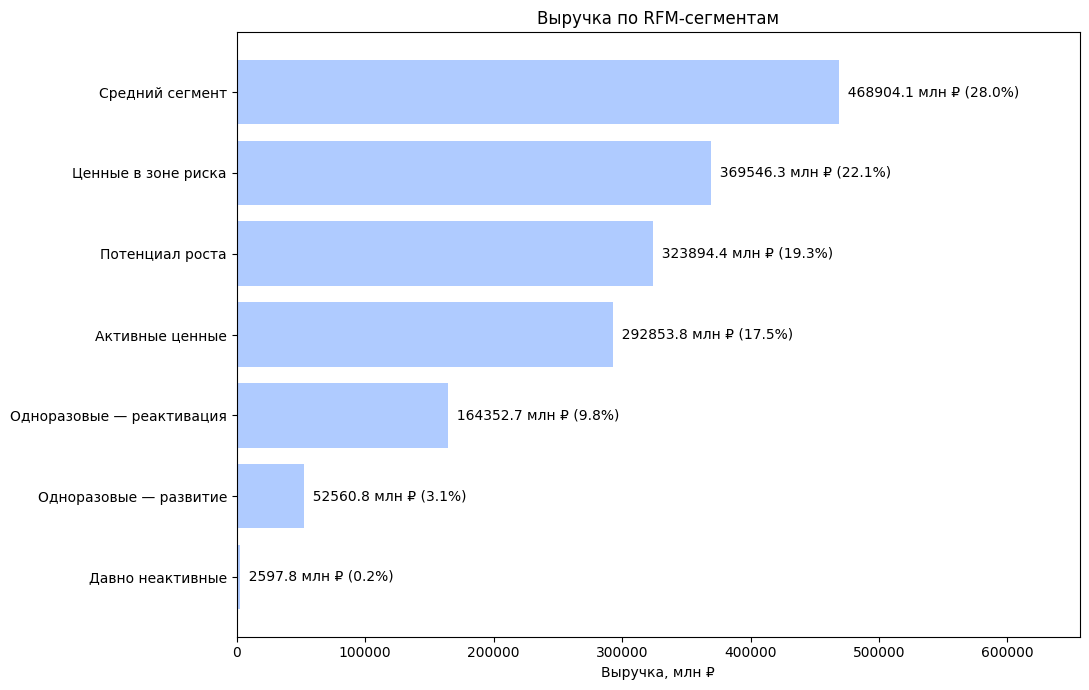

In [66]:
rfm_plot = (
    final_segment_summary
    .sort_values("revenue", ascending=True)
    .copy()
)

rfm_plot["revenue_mln"] = (
    rfm_plot["revenue"] / 1000000
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    rfm_plot["final_segment"],
    rfm_plot["revenue_mln"],
    color="#AFCBFF"
)

plt.title("Выручка по RFM-сегментам")
plt.xlabel("Выручка, млн ₽")
plt.ylabel("")
plt.xlim(
    0,
    rfm_plot["revenue_mln"].max() * 1.4
)

for bar, share in zip(
    bars,
    rfm_plot["revenue_share"]
):
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"  {value:.1f} млн ₽ ({share:.1f}%)",
        va="center"
    )

plt.tight_layout()
plt.show()

#### **Сценарий роста для клиентов с 2 покупками**

In [32]:
two_purchase_active = rfm[
    (rfm["frequency"] == 2) &
    (rfm["recency"] <= 90)
].copy()

# средняя выручка за 1 покупку, а не вся историческая сумма
avg_revenue_per_purchase = (
    two_purchase_active["monetary"] / two_purchase_active["frequency"]
).mean()

print(f"Клиентов с 2 покупками и recency ≤ 90: {len(two_purchase_active):,}")
print(f"Средняя выручка за 1 покупку: {avg_revenue_per_purchase:,.0f} ₽")

scenario_two_purchase = pd.DataFrame({
    "conversion_rate": [0.05, 0.10, 0.15, 0.20]
})

scenario_two_purchase["additional_clients"] = (
    len(two_purchase_active) * scenario_two_purchase["conversion_rate"]
).round(0).astype(int)

scenario_two_purchase["additional_revenue"] = (
    scenario_two_purchase["additional_clients"] * avg_revenue_per_purchase
)

scenario_two_purchase["additional_revenue_mln"] = (
    scenario_two_purchase["additional_revenue"] / 1_000_000
).round(1)

scenario_two_purchase

Клиентов с 2 покупками и recency ≤ 90: 115,316
Средняя выручка за 1 покупку: 818,222 ₽


,conversion_rate,additional_clients,additional_revenue,additional_revenue_mln
0,0.05,5766,4.717868e+09,4717.9
1,0.10,11532,9.435735e+09,9435.7
2,0.15,17297,1.415278e+10,14152.8
3,0.20,23063,1.887065e+10,18870.7


#### **Сценарий роста для клиентов одноразовых клиентов**

In [33]:
# Сценарий роста для одноразовых клиентов (1 → 2 покупки)
one_time_active = rfm[
    (rfm["frequency"] == 1) &
    (rfm["recency"] <= 90)
].copy()

# Для one-time средняя выручка за покупку = monetary
avg_revenue_one_time = one_time_active["monetary"].mean()

print(f"Одноразовых клиентов с recency ≤ 90: {len(one_time_active):,}")
print(f"Средняя выручка за покупку: {avg_revenue_one_time:,.0f} ₽")

scenario_one_time = pd.DataFrame({
    "conversion_rate": [0.05, 0.10, 0.15, 0.20]
})

scenario_one_time["additional_clients"] = (
    len(one_time_active) * scenario_one_time["conversion_rate"]
).round(0).astype(int)

scenario_one_time["additional_revenue"] = (
    scenario_one_time["additional_clients"] * avg_revenue_one_time
)

scenario_one_time["additional_revenue_mln"] = (
    scenario_one_time["additional_revenue"] / 1_000_000
).round(1)

scenario_one_time

Одноразовых клиентов с recency ≤ 90: 64,086
Средняя выручка за покупку: 820,160 ₽


,conversion_rate,additional_clients,additional_revenue,additional_revenue_mln
0,0.05,3204,2.627791e+09,2627.8
1,0.10,6409,5.256403e+09,5256.4
2,0.15,9613,7.884195e+09,7884.2
3,0.20,12817,1.051199e+10,10512.0


In [34]:
client_purchase_metrics = (
    df.groupby("client_id")
      .agg(
          transactions=("purchase_datetime", "size"),
          quantity=("quantity", "sum"),
          revenue=("total_price", "sum"),
          unique_products=("product_id", "nunique")
      )
      .reset_index()
)

client_purchase_metrics["avg_revenue_per_transaction"] = (
    client_purchase_metrics["revenue"]
    / client_purchase_metrics["transactions"]
)

frequency_value = (
    client_purchase_metrics
    .groupby("transactions")
    .agg(
        clients=("client_id", "count"),
        avg_revenue_per_transaction=(
            "avg_revenue_per_transaction", "mean"
        ),
        avg_unique_products=("unique_products", "mean")
    )
    .reset_index()
)

frequency_value.head(6).round(2)

,transactions,clients,avg_revenue_per_transaction,avg_unique_products
0,1,264955,818680.24,1.0
1,2,270786,818996.33,2.0
2,3,183940,822982.16,3.0
3,4,94111,822860.26,4.0
4,5,38285,819583.47,5.0
5,6,12921,821402.38,6.0


#### **Клиентская база и историческая ценность**

In [35]:
# Историческая ценность клиента за 2023 год 
client = (
    df.groupby("client_id")
      .agg(
          first_purchase=("purchase_datetime", "min"),
          last_purchase=("purchase_datetime", "max"),
          frequency=("purchase_datetime", "size"),
          historical_revenue=("total_price", "sum")  
      )
      .reset_index()
)

client["days_active"] = (
    client["last_purchase"] - client["first_purchase"]
).dt.days

client["revenue_per_purchase"] = (
    client["historical_revenue"] / client["frequency"]
)

client.describe().round(2)

,client_id,first_purchase,last_purchase,frequency,historical_revenue,days_active,revenue_per_purchase
count,869966.00,869966,869966,869966.00,869966.00,869966.00,869966.00
mean,500156.90,2023-05-05 15:44:44.786302720,2023-08-28 22:46:42.961955072,2.35,1925028.91,115.29,820226.03
min,0.00,2023-01-01 00:00:00,2023-01-01 00:00:00,1.00,0.00,0.00,0.00
25%,250280.25,2023-02-17 00:00:00,2023-06-26 00:00:00,1.00,456600.50,0.00,254926.00
50%,500186.00,2023-04-13 00:00:00,2023-09-18 00:00:00,2.00,1316745.50,100.00,595837.00
75%,750249.75,2023-07-08 00:00:00,2023-11-19 00:00:00,3.00,2796604.75,207.00,1127138.00
max,999998.00,2023-12-31 00:00:00,2023-12-31 00:00:00,12.00,21738645.00,364.00,9393300.00
std,288692.85,NaN,NaN,1.28,1943921.45,108.21,805509.86


In [70]:
# Когортная оценка перехода от первой ко второй покупке.
# Для клиентов, совершивших первую покупку в последние 90 дней, еще не было полного периода для оценки повторной покупки.
# Поэтому исключаем их из расчета.

if "client_id" not in client.columns:

    # Если client_id оказался индексом
    if client.index.name == "client_id":
        client = client.reset_index()

    else:
        raise KeyError(
            "В DataFrame client отсутствует client_id "
            "и в столбцах, и в индексе."
        )

client = client.drop(
    columns=[
        "second_purchase",
        "days_to_second",
        "repeat_90d"
    ],
    errors="ignore"
)

# Находим дату второй покупки каждого клиента
second_purchase = (
    df.sort_values(
        ["client_id", "purchase_datetime"]
    )
    .groupby("client_id")["purchase_datetime"]
    .nth(1)
)

# Добавляем дату второй покупки
client["second_purchase"] = (
    client["client_id"]
    .map(second_purchase)
)

# Количество дней от первой до второй покупки
client["days_to_second"] = (
    client["second_purchase"]
    - client["first_purchase"]
).dt.days

# Последняя дата в данных
analysis_date = df["purchase_datetime"].max()

# Оставляем только клиентов, для которых прошло минимум 90 дней с первой покупки
eligible_90d = client[
    client["first_purchase"]
    <= analysis_date - pd.Timedelta(days=90)
].copy()

# Факт повторной покупки в течение 90 дней
eligible_90d["repeat_90d"] = (
    eligible_90d["days_to_second"].notna()
    & (eligible_90d["days_to_second"] <= 90)
)

# Конверсия первой покупки во вторую
conversion_90d = (eligible_90d["repeat_90d"].mean() * 100)


print(
    f"Клиентов с полным 90-дневным окном: "
    f"{len(eligible_90d):,}"
)

print(
    f"Клиентов, совершивших 2-ю покупку "
    f"в течение 90 дней: "
    f"{eligible_90d['repeat_90d'].sum():,}"
)

print(
    f"Конверсия в 2-ю покупку в течение 90 дней: "
    f"{conversion_90d:.1f}%"
)

Клиентов с полным 90-дневным окном: 788,638
Клиентов, совершивших 2-ю покупку в течение 90 дней: 171,957
Конверсия в 2-ю покупку в течение 90 дней: 21.8%


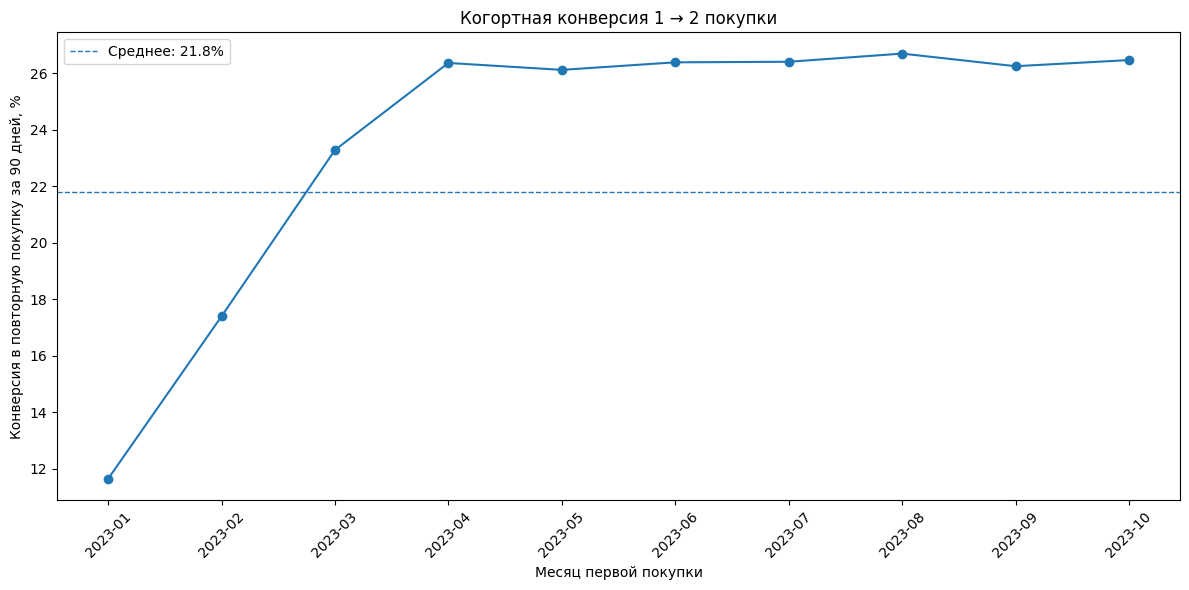

In [71]:
# Когортная динамика 90-дневной конверсии
eligible_90d["cohort_month"] = (
    eligible_90d["first_purchase"].dt.to_period("M").astype(str)
)

cohort_conversion = (
    eligible_90d.groupby("cohort_month")
                .agg(
                    clients=("client_id", "count"),
                    repeat_90d=("repeat_90d", "mean")
                )
                .reset_index()
)

cohort_conversion["repeat_90d_pct"] = (
    cohort_conversion["repeat_90d"] * 100
)

plt.figure(figsize=(12, 6))
plt.plot(
    cohort_conversion["cohort_month"],
    cohort_conversion["repeat_90d_pct"],
    marker="o"
)
plt.axhline(
    conversion_90d,
    linestyle="--",
    linewidth=1,
    label=f"Среднее: {conversion_90d:.1f}%"
)
plt.xticks(rotation=45)
plt.xlabel("Месяц первой покупки")
plt.ylabel("Конверсия в повторную покупку за 90 дней, %")
plt.title("Когортная конверсия 1 → 2 покупки")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# Декомпозиция исторической выручки по частоте покупок
frequency_ltv = (
    client.groupby("frequency")
          .agg(
              clients=("client_id", "count"),
              avg_historical_revenue=("historical_revenue", "mean"),
              avg_revenue_per_purchase=("revenue_per_purchase", "mean")
          )
          .reset_index()
)

frequency_ltv["client_share_pct"] = (
    frequency_ltv["clients"] / frequency_ltv["clients"].sum() * 100
).round(2)

frequency_ltv.head(12).round(2)

,frequency,clients,avg_historical_revenue,avg_revenue_per_purchase,client_share_pct
0,1,264955,818680.24,818680.24,30.46
1,2,270786,1637992.67,818996.33,31.13
2,3,183940,2468946.47,822982.16,21.14
3,4,94111,3291441.04,822860.26,10.82
4,5,38285,4097917.36,819583.47,4.40
5,6,12921,4928414.25,821402.38,1.49
6,7,3742,5748276.64,821182.38,0.43
7,8,959,6450320.87,806290.11,0.11
8,9,213,7623008.08,847000.90,0.02
9,10,44,8526298.16,852629.82,0.01


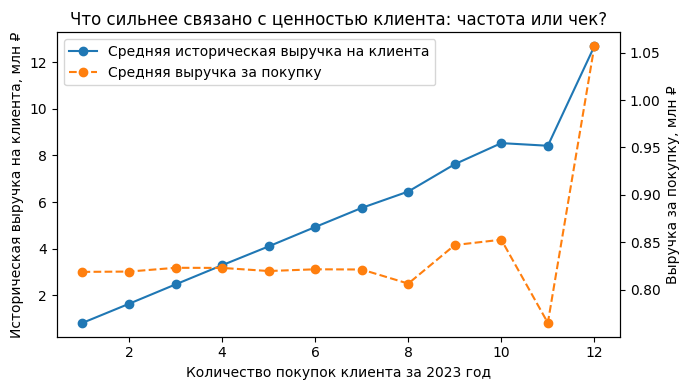

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    frequency_ltv["frequency"],
    frequency_ltv["avg_historical_revenue"] / 1e6,
    marker="o",
    label="Средняя историческая выручка на клиента"
)

ax2 = ax.twinx()
ax2.plot(
    frequency_ltv["frequency"],
    frequency_ltv["avg_revenue_per_purchase"] / 1e6,
    marker="o",
    linestyle="--",
    color="C1",
    label="Средняя выручка за покупку"
)

ax.set_xlabel("Количество покупок клиента за 2023 год")
ax.set_ylabel("Историческая выручка на клиента, млн ₽")
ax2.set_ylabel("Выручка за покупку, млн ₽")
ax.set_title("Что сильнее связано с ценностью клиента: частота или чек?")

# Легенды
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()